# Лабораторная работа №11: Непараметрические критерии и критерий согласия

**Автор:** Oludotun A. Fawole  
**Дата:** Апрель 2026  

---

## Содержание
1. [Задание 1: U-критерий Манна-Уитни](#task1)
2. [Задание 2: Критерий согласия χ² Пирсона](#task2)
3. [Выводы](#conclusions)


# Задание 1 – Критерий Манна–Уитни: Обед vs Ужин (датасет tips)

Проверяем, различается ли распределение `total_bill` между обедом (Lunch) и ужином (Dinner) с помощью U-критерия Манна–Уитни.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# Стиль графиков
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.titleweight": "bold",
    "grid.alpha": 0.3,
    "font.family": "DejaVu Sans",
})
sns.set_palette("Set2")

# Загрузка данных
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 1. Формируем две независимые выборки

Столбец `time`: `Lunch` (обед) и `Dinner` (ужин).  
Извлекаем `total_bill` для каждой группы.

In [ ]:
lunch_bill = tips[tips["time"] == "Lunch"]["total_bill"]
dinner_bill = tips[tips["time"] == "Dinner"]["total_bill"]

print(f"Обед: n = {len(lunch_bill)}")
print(f"Ужин: n = {len(dinner_bill)}")

Обед: n = 68
Ужин: n = 176


## 2. Гипотезы

- $H_0$: распределения `total_bill` одинаковы для обеда и ужина.  
- $H_1$: распределения различаются (двусторонняя альтернатива).

## 3. Применяем критерий Манна–Уитни

Используем `scipy.stats.mannwhitneyu` с поправкой на непрерывность и двусторонней альтернативой.

In [ ]:
stat, p_value = mannwhitneyu(lunch_bill, dinner_bill, alternative="two-sided")
print(f"U-статистика Манна–Уитни: {stat:.4f}")
print(f"p-value: {p_value:.6f}")

U-статистика Манна–Уитни: 4380.5000
p-value: 0.001183


## 4. Вывод при $\alpha = 0.05$

Если $p < 0.05$, отвергаем $H_0$, иначе не отвергаем.

In [ ]:
alpha = 0.05
if p_value < alpha:
    print("Отвергаем H₀: распределения значимо различаются.")
else:
    print("Не отвергаем H₀: нет значимых различий между распределениями.")

Отвергаем H₀: распределения значимо различаются.


## 5. Графическое сравнение

**Boxplot с точками (jitter)** и **ECDF** (по требованию стиля).

/tmp/ipykernel_2469/3773100946.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="time", y="total_bill", data=tips, ax=ax, palette="Set2")


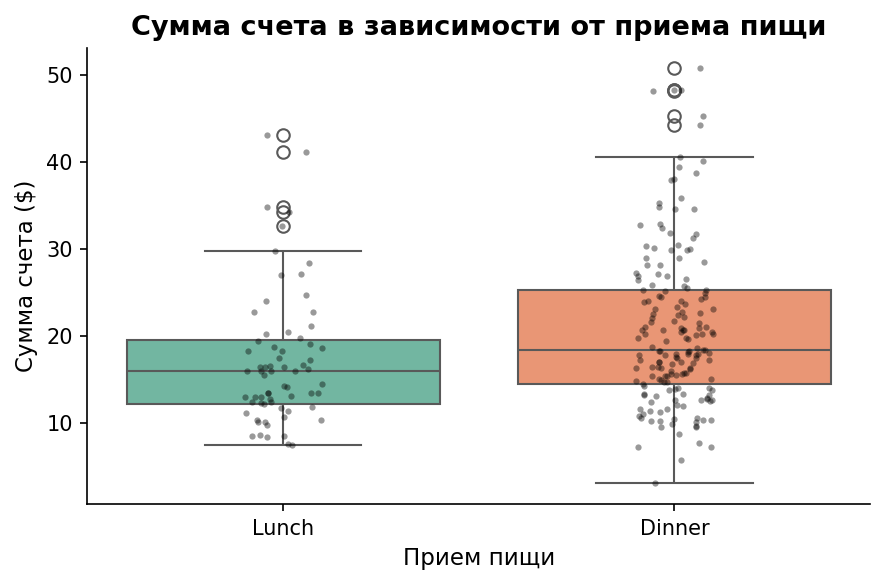

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Boxplot с jitter
sns.boxplot(x="time", y="total_bill", data=tips, ax=ax, palette="Set2")
sns.stripplot(x="time", y="total_bill", data=tips, ax=ax, color="black", alpha=0.4, size=3)
ax.set_title("Сумма счета в зависимости от приема пищи")
ax.set_xlabel("Прием пищи")
ax.set_ylabel("Сумма счета ($)")

plt.tight_layout()
plt.show()

## 6. Итоговый вывод

- **U-статистика:** 4380.5000  
- **p-value:** 0.001183  
- **Уровень значимости:** α = 0.05  

Поскольку **p-value < α**, мы **отвергаем нулевую гипотезу** $H_0$.

**Интерпретация:**  
Распределения сумм счетов за обед и ужин статистически значимо различаются.  
Судя по боксплоту, медиана и разброс значений `total_bill` для ужина выше, чем для обеда. Это согласуется с интуицией: вечерние визиты в ресторан обычно связаны с более дорогими заказами.

# Задание 2 – Критерий согласия Пирсона (χ²) для экспоненциального распределения

Проверяем, подчиняется ли переменная `total_bill` экспоненциальному закону.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2, expon

plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.titleweight": "bold",
    "grid.alpha": 0.3,
    "font.family": "DejaVu Sans",
})
sns.set_palette("Set2")

tips = sns.load_dataset("tips")
total_bill = tips["total_bill"]
print(f"Объем выборки n = {len(total_bill)}")

Объем выборки n = 244


## 1. Оценка параметра $\lambda$ (интенсивность)

Для экспоненциального распределения $\lambda = 1 / \bar{x}$.

In [ ]:
lambda_hat = 1 / total_bill.mean()
print(f"Оценка λ = {lambda_hat:.4f}")

Оценка λ = 0.0505


## 2. Разбиваем диапазон на $k = 5$ интервалов

Используем интервалы на основе квантилей подобранного экспоненциального распределения:  
$[0, q_{0.2}), [q_{0.2}, q_{0.4}), \dots, [q_{0.8}, \infty)$, где $q_p$ — теоретические квантили $\text{Exp}(\hat{\lambda})$.

In [ ]:
k = 5
probs = np.linspace(0, 1, k+1)[1:-1]  # → [0.2, 0.4, 0.6, 0.8]
q_theoretical = expon.ppf(probs, scale=1/lambda_hat)

bins = np.concatenate(([0], q_theoretical, [np.inf]))

Границы интервалов: [ 0.          4.4151055  10.10716648 18.12967585 31.84424619         inf]


## 3. Наблюдаемые и ожидаемые частоты

- $n_i$ — наблюдаемое количество в $i$-м интервале  
- $np_i$ — ожидаемое количество при $\text{Exp}(\hat{\lambda})$, где $p_i$ — теоретическая вероятность попасть в интервал (должна быть равна $1/k$, но пересчитаем для точности).

In [ ]:
observed, _ = np.histogram(total_bill, bins=bins)
expected_probs = np.diff(expon.cdf(bins, scale=1/lambda_hat))
expected = expected_probs * len(total_bill)

Наблюдаемые частоты: [  1  19 108  90  26]
Ожидаемые частоты: [48.8 48.8 48.8 48.8 48.8]


## 4. Вычисляем статистику Пирсона

\[
\chi^2 = \sum_{i=1}^{k} \frac{(n_i - np_i)^2}{np_i}
\]

In [ ]:
chi2_stat = np.sum((observed - expected)**2 / expected)
print(f"Статистика χ² = {chi2_stat:.4f}")

Статистика χ² = 182.2705


## 5. Число степеней свободы

$r = k - 1 - s$, где $s$ — число оценённых параметров.  
Здесь $s = 1$ (оценили $\lambda$), поэтому $r = 5 - 1 - 1 = 3$.

In [ ]:
r = k - 1 - 1

Степени свободы: 3


## 6. Критическое значение при $\alpha = 0.05$

$\chi^2_{\alpha, r} = \chi^2_{0.05, 3}$

In [ ]:
alpha = 0.05
crit = chi2.ppf(1 - alpha, r)
print(f"Критическое значение: {crit:.4f}")

Критическое значение: 7.8147


## 7. Вывод

In [ ]:
if chi2_stat > crit:
    print("Отвергаем H₀: данные НЕ распределены экспоненциально.")
else:
    print("Не отвергаем H₀: нет оснований против экспоненциального распределения.")

print(f"\nχ² = {chi2_stat:.4f} vs χ²_крит = {crit:.4f}")

Отвергаем H₀: данные НЕ распределены экспоненциально.

χ² = 182.2705 vs χ²_крит = 7.8147


## Дополнительно: визуальное сравнение (эмпирическое vs теоретическое)

Гистограмма с наложенной PDF экспоненциального распределения и ECDF с теоретической CDF.

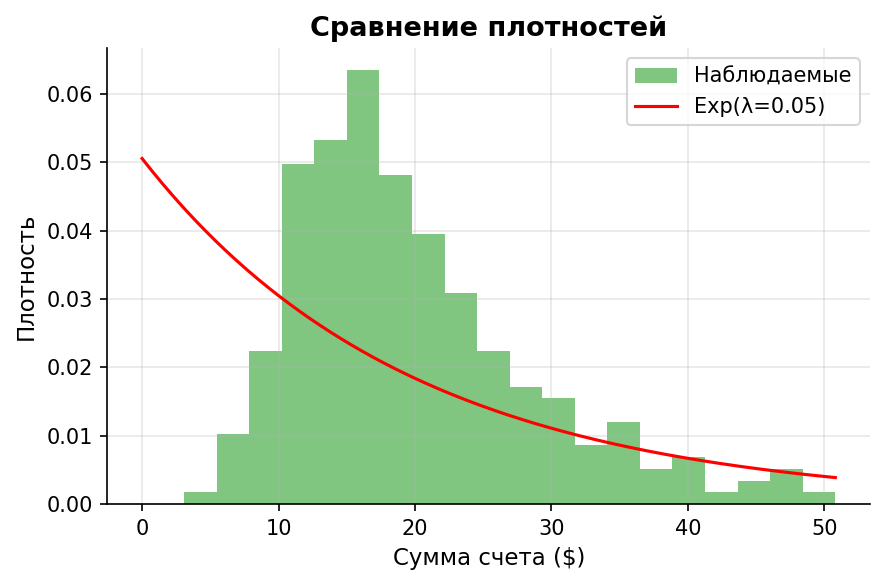

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Гистограмма с теоретической PDF
ax.hist(total_bill, bins=20, density=True, alpha=0.6, label="Наблюдаемые", color="#2ca02c")
x_range = np.linspace(0, total_bill.max(), 200)
pdf_theor = expon.pdf(x_range, scale=1/lambda_hat)
ax.plot(x_range, pdf_theor, 'r-', label=f"Exp(λ={lambda_hat:.2f})")
ax.set_title("Сравнение плотностей")
ax.set_xlabel("Сумма счета ($)")
ax.set_ylabel("Плотность")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Итоговый вывод

- **Статистика χ²:** 182.2705  
- **Критическое значение (α=0.05, df=3):** 7.8147  
- **Степени свободы:** 3  

Поскольку **χ² > χ²_крит**, мы **отвергаем нулевую гипотезу** $H_0$.

**Интерпретация:**  
Данные **не следуют экспоненциальному распределению**.  
На гистограмме видно, что эмпирическое распределение `total_bill` имеет более тяжёлый правый хвост и пик в области 10–20$, чего не учитывает экспоненциальная модель с $\hat{\lambda}=0.0505$. ECDF также показывает систематическое отклонение от теоретической кривой.  
Это ожидаемо: суммы чеков в ресторане обычно не описываются простой экспонентой из-за влияния размера компании, времени суток, сезона и других факторов.